# ============================================================
# RETAIL SALES ANALYSIS & PROFITABILITY PREDICTION
# ============================================================

## Project Overview

This project focuses on analyzing retail sales order data using:
- Python
- Pandas
- MySQL
- Data Visualization
- Machine Learning

The project workflow includes:
1. Data Cleaning & Feature Engineering
2. SQL-Based Exploratory Data Analysis
3. Machine Learning Based Profitability Prediction

The objective is to derive business insights from retail transactions and build predictive models capable of identifying profitable and loss-making orders.

In [1]:
# ============================================================
# Importing Dependencies
# ============================================================

import kaggle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option('display.max_rows', None)

## Dataset Import

The retail orders dataset was downloaded from Kaggle and extracted locally for analysis.

In [2]:
# ============================================================
# Downloading Kaggle Dataset
# ============================================================

!kaggle datasets download ankitbansal06/retail-orders -f orders.csv

Dataset URL: https://www.kaggle.com/datasets/ankitbansal06/retail-orders
License(s): CC0-1.0
orders.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
# ============================================================
# Extracting Dataset
# ============================================================

import zipfile

zip_ref = zipfile.ZipFile('orders.csv.zip')

zip_ref.extractall()

zip_ref.close()

print("Dataset extracted successfully.")

Dataset extracted successfully.


## Creating DataFrame

The dataset is loaded into a Pandas DataFrame.

The values:
- `Not Available`
- `unknown`

are treated as missing values during import.

In [4]:
# ============================================================
# Loading Dataset into DataFrame
# ============================================================

df = pd.read_csv(
    'orders.csv',
    na_values=[
        'Not Available',
        'unknown'
    ]
)

df.head()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [5]:
# ============================================================
# Initial Dataset Inspection
# ============================================================

print("Dataset Shape :", df.shape)

print("\nDataset Information:\n")

df.info()

Dataset Shape : (9994, 16)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order Id          9994 non-null   int64 
 1   Order Date        9994 non-null   object
 2   Ship Mode         9988 non-null   object
 3   Segment           9994 non-null   object
 4   Country           9994 non-null   object
 5   City              9994 non-null   object
 6   State             9994 non-null   object
 7   Postal Code       9994 non-null   int64 
 8   Region            9994 non-null   object
 9   Category          9994 non-null   object
 10  Sub Category      9994 non-null   object
 11  Product Id        9994 non-null   object
 12  cost price        9994 non-null   int64 
 13  List Price        9994 non-null   int64 
 14  Quantity          9994 non-null   int64 
 15  Discount Percent  9994 non-null   int64 
dtypes: int64(6

## Missing Value Analysis

The dataset is checked for missing values to identify columns requiring preprocessing.

In [6]:
# ============================================================
# Checking Missing Values
# ============================================================

df.isnull().sum()

Order Id            0
Order Date          0
Ship Mode           6
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64

In [7]:
# ============================================================
# Inspecting Missing Values in Ship Mode
# ============================================================

df[df['Ship Mode'].isna()]

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
5,6,2022-03-13,NaN,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,FUR-FU-10001487,50,50,7,3
8,9,2023-03-23,NaN,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,OFF-BI-10003910,20,20,3,2
10,11,2023-03-31,NaN,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,FUR-TA-10001539,1470,1710,9,3
11,12,2023-12-25,NaN,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,TEC-PH-10002033,750,910,4,3
14,15,2023-11-09,NaN,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,OFF-AP-10002311,60,70,5,5
118,119,2023-07-19,NaN,Corporate,United States,Bristol,Tennessee,37620,South,Office Supplies,Binders,OFF-BI-10003650,140,160,1,5


## Column Name Standardization

Column names are standardized by:
- converting to lowercase
- replacing spaces with underscores

This improves readability and consistency throughout the project.

In [8]:
# ============================================================
# Standardizing Column Names
# ============================================================

df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['order_id', 'order_date', 'ship_mode', 'segment', 'country', 'city',
       'state', 'postal_code', 'region', 'category', 'sub_category',
       'product_id', 'cost_price', 'list_price', 'quantity',
       'discount_percent'],
      dtype='object')

## Datetime Conversion

The `order_date` column is converted from object datatype to datetime format for time-based analysis and feature engineering.

In [9]:
# ============================================================
# Converting Order Date to Datetime
# ============================================================

df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%Y-%m-%d'
)

print(df['order_date'].dtype)

datetime64[ns]


## Categorical Feature Inspection

Unique values of categorical columns are inspected to understand dataset composition and identify potential inconsistencies.

In [10]:
# ============================================================
# Displaying Categorical Column Values
# ============================================================

non_cat_col = [
    'order_id',
    'order_date',
    'product_id',
    'cost_price',
    'list_price',
    'quantity',
    'discount_percent',
    'city',
    'sub_category',
    'postal_code',
    'state'
]

print("Categorical Columns:\n")

for col in df.columns:

    if col not in non_cat_col:

        print(col, ":\n", df[col].unique())

        print("-" * 70)

Categorical Columns:

ship_mode :
 ['Second Class' 'Standard Class' nan 'First Class' 'Same Day']
----------------------------------------------------------------------
segment :
 ['Consumer' 'Corporate' 'Home Office']
----------------------------------------------------------------------
country :
 ['United States']
----------------------------------------------------------------------
region :
 ['South' 'West' 'Central' 'East']
----------------------------------------------------------------------
category :
 ['Furniture' 'Office Supplies' 'Technology']
----------------------------------------------------------------------


In [11]:
# Displaying all the catagorical colums 
non_cat_col=['order_id','order_date','product_id', 'cost_price', 'list_price','quantity', 'discount_percent','city','sub_category','postal_code','state']

print('Column Name')
for col in df.columns:
    if col not in non_cat_col:
        print(col,':',df[col].unique())
        print('-'*70)

Column Name
ship_mode : ['Second Class' 'Standard Class' nan 'First Class' 'Same Day']
----------------------------------------------------------------------
segment : ['Consumer' 'Corporate' 'Home Office']
----------------------------------------------------------------------
country : ['United States']
----------------------------------------------------------------------
region : ['South' 'West' 'Central' 'East']
----------------------------------------------------------------------
category : ['Furniture' 'Office Supplies' 'Technology']
----------------------------------------------------------------------


## Removing Redundant Columns

The `country` column is removed because it contains only a single unique value and does not contribute meaningful analytical information.

In [12]:
# ============================================================
# Dropping Country Column
# ============================================================

df.drop(
    columns='country',
    inplace=True
)

df.head()

,order_id,order_date,ship_mode,segment,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent
0,1,2023-03-01,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [13]:
# ============================================================
# Removing Duplicate Rows
# ============================================================

df.drop_duplicates(
    keep='first',
    inplace=True
)

print("Dataset Shape After Removing Duplicates :")

print(df.shape)

Dataset Shape After Removing Duplicates :
(9994, 15)


## Feature Engineering

Additional features are derived to support business analysis and machine learning.

Generated features include:
- Year
- Month
- Discount
- Sales Price
- Total Revenue
- Profit

In [14]:
# ============================================================
# Creating New Features
# ============================================================

# Extracting year and month

df['year'] = (
    df['order_date']
    .dt.year
)

df['month'] = (
    df['order_date']
    .dt.month
)

# Calculating discount amount

df['discount'] = (
    df['list_price']
    * (
        df['discount_percent'] / 100
    )
)

# Calculating sales price

df['sales_price'] = (
    df['list_price']
    - df['discount']
)

# Calculating total revenue

df['total_revenue'] = (
    df['sales_price']
    * df['quantity']
)

# Calculating profit

df['profit'] = (
    (
        df['sales_price']
        - df['cost_price']
    )
    * df['quantity']
)

df.head()

,order_id,order_date,ship_mode,segment,city,state,postal_code,region,category,sub_category,...,cost_price,list_price,quantity,discount_percent,year,month,discount,sales_price,total_revenue,profit
0,1,2023-03-01,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,...,240,260,2,2,2023,3,5.2,254.8,509.6,29.6
1,2,2023-08-15,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,...,600,730,3,3,2023,8,21.9,708.1,2124.3,324.3
2,3,2023-01-10,Second Class,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,...,10,10,2,5,2023,1,0.5,9.5,19.0,-1.0
3,4,2022-06-18,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Furniture,Tables,...,780,960,5,2,2022,6,19.2,940.8,4704.0,804.0
4,5,2022-07-13,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,...,20,20,2,5,2022,7,1.0,19.0,38.0,-2.0


In [15]:
# ============================================================
# Final Cleaned Dataset
# ============================================================

print("Final Dataset Shape :", df.shape)

df.head()

Final Dataset Shape : (9994, 21)


,order_id,order_date,ship_mode,segment,city,state,postal_code,region,category,sub_category,...,cost_price,list_price,quantity,discount_percent,year,month,discount,sales_price,total_revenue,profit
0,1,2023-03-01,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,...,240,260,2,2,2023,3,5.2,254.8,509.6,29.6
1,2,2023-08-15,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,...,600,730,3,3,2023,8,21.9,708.1,2124.3,324.3
2,3,2023-01-10,Second Class,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,...,10,10,2,5,2023,1,0.5,9.5,19.0,-1.0
3,4,2022-06-18,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Furniture,Tables,...,780,960,5,2,2022,6,19.2,940.8,4704.0,804.0
4,5,2022-07-13,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,...,20,20,2,5,2022,7,1.0,19.0,38.0,-2.0


# ============================================================
# SQL-BASED EXPLORATORY DATA ANALYSIS
# ============================================================

## Objective

The objective of this section is to perform business-oriented exploratory data analysis using SQL queries on a MySQL database.

The workflow includes:
- Creating a SQL-specific dataframe
- Loading data into MySQL
- Performing business analysis using SQL queries
- Visualizing insights using Python

## Creating SQL DataFrame

A dedicated dataframe is created specifically for SQL analysis and business intelligence reporting.

The dataframe retains:
- transactional information
- pricing information
- revenue and profit metrics

# Feeding the dataframe into Mysql server

In [16]:
# ============================================================
# Creating SQL DataFrame
# ============================================================

df_sql = df[
    [
        'order_id',
        'order_date',
        'ship_mode',
        'segment',
        'city',
        'state',
        'postal_code',
        'region',
        'category',
        'sub_category',
        'product_id',
        'quantity',
        'discount_percent',
        'discount',
        'sales_price',
        'total_revenue',
        'profit'
    ]
]

df_sql.head()

,order_id,order_date,ship_mode,segment,city,state,postal_code,region,category,sub_category,product_id,quantity,discount_percent,discount,sales_price,total_revenue,profit
0,1,2023-03-01,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,2,2,5.2,254.8,509.6,29.6
1,2,2023-08-15,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,3,3,21.9,708.1,2124.3,324.3
2,3,2023-01-10,Second Class,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,2,5,0.5,9.5,19.0,-1.0
3,4,2022-06-18,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,5,2,19.2,940.8,4704.0,804.0
4,5,2022-07-13,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,2,5,1.0,19.0,38.0,-2.0


## Order ID Validation

The uniqueness of `order_id` is verified to evaluate its suitability as a primary key in the MySQL table.

In [17]:
# ============================================================
# Checking Order ID Uniqueness
# ============================================================

print("Total Rows :",
      len(df_sql))

print("Unique Order IDs :",
      df_sql['order_id'].nunique())

Total Rows : 9994
Unique Order IDs : 9994


## Connecting to MySQL Server

A connection is established between Python and the MySQL database using SQLAlchemy.

In [18]:
# ============================================================
# Connecting to MySQL
# ============================================================

username = "your_username"

password = "your_password"

host = "localhost"

port = "3306"

database = "retail_sales_analysis_project"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

print("MySQL connection established successfully.")

MySQL connection established successfully.


## Loading Data into MySQL

The processed dataframe is loaded into the MySQL database for SQL-based analysis.

In [19]:
# ============================================================
# Exporting DataFrame to MySQL
# ============================================================

'''
df_sql.to_sql(
    name='orders',
    con=engine,
    if_exists='append',
    index=False
)
'''

print("Data exported successfully.")

Data exported successfully.


In [20]:
# ============================================================
# Validating Imported Data
# ============================================================

pd.read_sql(
    'SELECT COUNT(*) FROM orders',
    engine
)

,COUNT(*)
0,9994


# ============================================================
# BUSINESS ANALYSIS USING SQL
# ============================================================

The following section explores key business questions related to:
- revenue
- profitability
- regional performance
- product performance
- discount impact
- monthly sales trends

## Q1. What is the total revenue, profit, and quantity sold?

In [21]:
# ============================================================
# Q1. Overall Business Performance
# ============================================================

query = """

SELECT
    SUM(total_revenue) AS total_revenue,
    SUM(profit) AS total_profit,
    SUM(quantity) AS total_quantity
FROM orders;

"""

df1 = pd.read_sql(
    query,
    engine
)

df1

,total_revenue,total_profit,total_quantity
0,11079328.2,1039928.2,37873.0


## Q2. Which categories generate the highest revenue?

In [22]:
# ============================================================
# Q2. Category Revenue Analysis
# ============================================================

query = """

SELECT
    category,
    SUM(total_revenue) AS revenue
FROM orders
GROUP BY category
ORDER BY revenue DESC;

"""

df2 = pd.read_sql(
    query,
    engine
)

df2

,category,revenue
0,Technology,3934910.7
1,Furniture,3720742.4
2,Office Supplies,3423675.1


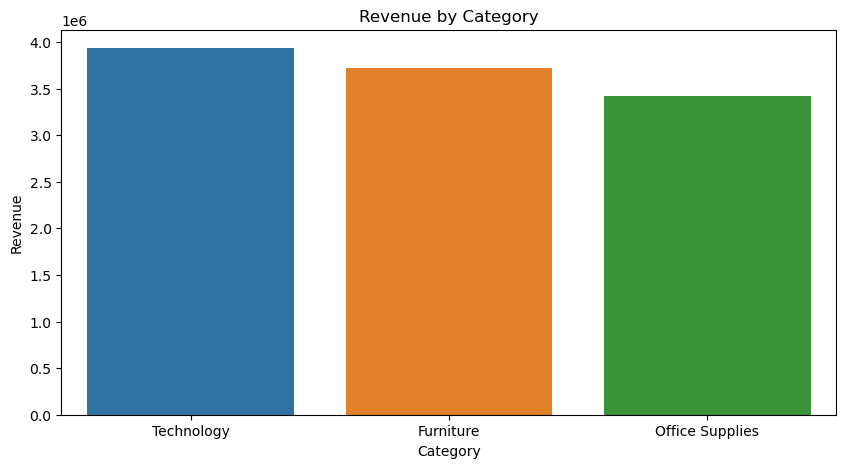

In [23]:
# ============================================================
# Visualizing Category Revenue
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df2,
    x='category',
    y='revenue',
    hue='category'
)

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.title("Revenue by Category")

plt.show()

## Q3. Which sub-categories are most profitable?

In [24]:
# ============================================================
# Q3. Sub-Category Profitability Analysis
# ============================================================

query = """

SELECT
    sub_category,
    SUM(profit) AS profit
FROM orders
GROUP BY sub_category
ORDER BY profit DESC;

"""

df3 = pd.read_sql(
    query,
    engine
)

df3

,sub_category,profit
0,Chairs,153905.7
1,Phones,139498.5
2,Binders,98802.8
3,Tables,98522.2
4,Storage,96105.3
5,Machines,91545.3
6,Accessories,79412.0
7,Copiers,69264.9
8,Appliances,54582.6
9,Bookcases,51270.8


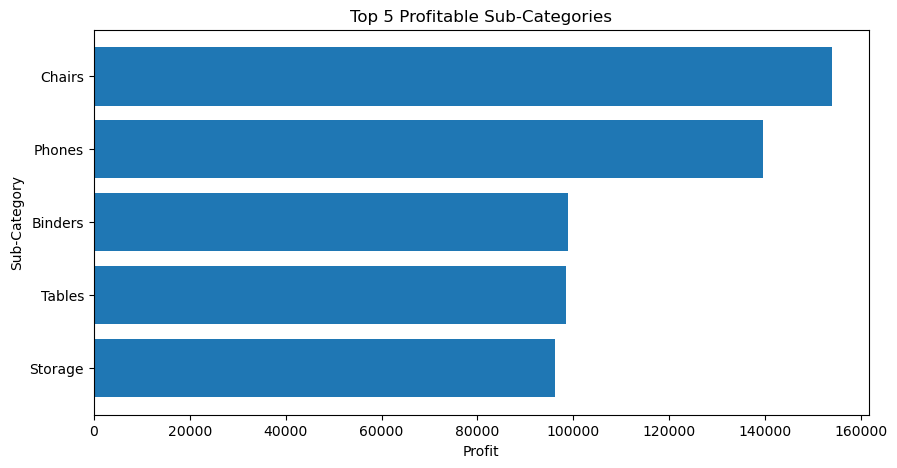

In [25]:
# ============================================================
# Visualizing Top Profitable Sub-Categories
# ============================================================

df_top5 = (
    df3
    .sort_values(
        by='profit',
        ascending=False
    )
    .head(5)
)

plt.figure(figsize=(10, 5))

plt.barh(
    df_top5['sub_category'],
    df_top5['profit']
)

plt.gca().invert_yaxis()

plt.xlabel("Profit")

plt.ylabel("Sub-Category")

plt.title(
    "Top 5 Profitable Sub-Categories"
)

plt.show()

## Q4. Which states generate the highest revenue?

In [26]:
# ============================================================
# Q4. State-Wise Revenue Analysis
# ============================================================

query = """

SELECT
    state,
    SUM(total_revenue) AS revenue
FROM orders
GROUP BY state
ORDER BY revenue DESC
LIMIT 10;

"""

df4 = pd.read_sql(
    query,
    engine
)

df4

,state,revenue
0,California,2219519.1
1,New York,1503857.1
2,Texas,804879.2
3,Washington,668161.2
4,Pennsylvania,581119.1
5,Florida,453911.3
6,Michigan,394727.5
7,Virginia,364309.2
8,Illinois,351414.2
9,Ohio,349806.0


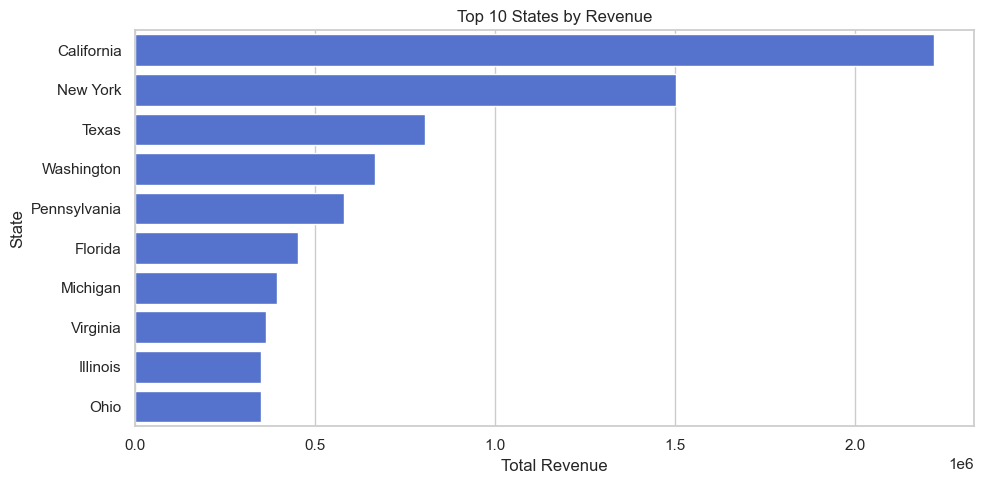

In [27]:
# ============================================================
# Visualizing Top Revenue Generating States
# ============================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df4,
    x='revenue',
    y='state',
    color='royalblue'
)

plt.xlabel("Total Revenue")

plt.ylabel("State")

plt.title(
    "Top 10 States by Revenue"
)

plt.tight_layout()

plt.show()

## Q5. Which cities are the most profitable?

In [28]:
# ============================================================
# Q5. City-Wise Profitability Analysis
# ============================================================

query = """

SELECT
    city,
    SUM(profit) AS profit
FROM orders
GROUP BY city
ORDER BY profit DESC
LIMIT 10;

"""

df5 = pd.read_sql(
    query,
    engine
)

df5

,city,profit
0,New York City,103852.6
1,Los Angeles,73294.8
2,Philadelphia,52619.3
3,Seattle,50765.7
4,San Francisco,48472.6
5,Jacksonville,29560.5
6,Houston,27982.9
7,Detroit,24813.1
8,San Diego,21398.4
9,Springfield,20499.1


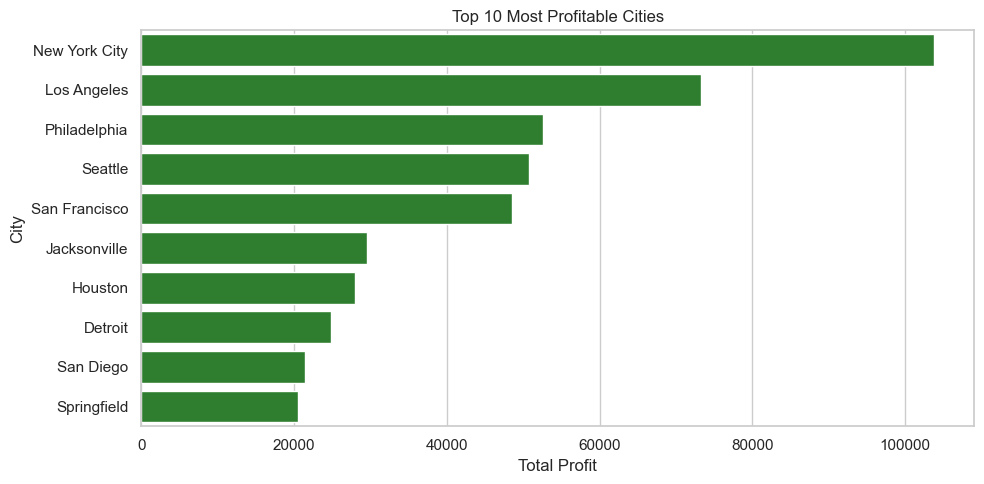

In [29]:
# ============================================================
# Visualizing Most Profitable Cities
# ============================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df5,
    x='profit',
    y='city',
    color='forestgreen'
)

plt.xlabel("Total Profit")

plt.ylabel("City")

plt.title(
    "Top 10 Most Profitable Cities"
)

plt.tight_layout()

plt.show()

## Q6. How does discount affect revenue and profit?

This analysis evaluates the relationship between discount percentages, revenue generation, and profitability.

In [30]:
# ============================================================
# Q6. Discount Impact Analysis
# ============================================================

query = """

SELECT
    discount_percent,
    AVG(profit) AS avg_profit,
    AVG(total_revenue) AS avg_revenue
FROM orders
GROUP BY discount_percent
ORDER BY discount_percent;

"""

df6 = pd.read_sql(
    query,
    engine
)

df6

,discount_percent,avg_profit,avg_revenue
0,2.0,113.276258,1057.180341
1,3.0,108.931668,1111.642132
2,4.0,101.214417,1095.787905
3,5.0,92.309005,1171.910156


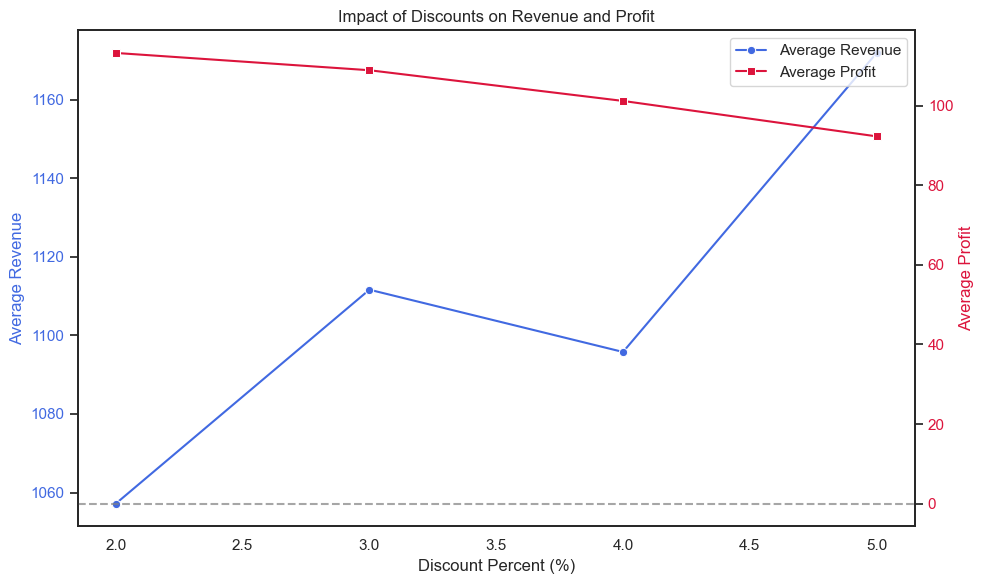

In [31]:
# ============================================================
# Visualizing Discount Impact
# ============================================================

sns.set_theme(style="white")

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df6,
    x='discount_percent',
    y='avg_revenue',
    color='royalblue',
    marker='o',
    ax=ax1,
    label='Average Revenue'
)

ax1.set_xlabel(
    "Discount Percent (%)"
)

ax1.set_ylabel(
    "Average Revenue",
    color='royalblue'
)

ax1.tick_params(
    axis='y',
    labelcolor='royalblue'
)

ax2 = ax1.twinx()

sns.lineplot(
    data=df6,
    x='discount_percent',
    y='avg_profit',
    color='crimson',
    marker='s',
    ax=ax2,
    label='Average Profit'
)

ax2.set_ylabel(
    "Average Profit",
    color='crimson'
)

ax2.tick_params(
    axis='y',
    labelcolor='crimson'
)

ax2.axhline(
    0,
    color='gray',
    linestyle='--',
    alpha=0.7
)

plt.title(
    "Impact of Discounts on Revenue and Profit"
)

lines1, labels1 = ax1.get_legend_handles_labels()

lines2, labels2 = ax2.get_legend_handles_labels()

ax1.get_legend().remove()

ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.tight_layout()

plt.show()

## Q7. Which products generate the highest revenue?

In [32]:
# ============================================================
# Q7. Product Revenue Analysis
# ============================================================

query = """

SELECT
    product_id,
    SUM(total_revenue) AS revenue
FROM orders
GROUP BY product_id
ORDER BY revenue DESC
LIMIT 10;

"""

df7 = pd.read_sql(
    query,
    engine
)

df7

,product_id,revenue
0,TEC-CO-10004722,245056.0
1,OFF-BI-10000545,163777.7
2,TEC-MA-10002412,130406.4
3,FUR-CH-10002024,120090.7
4,TEC-PH-10001459,113041.9
5,TEC-CO-10001449,107388.0
6,OFF-BI-10003527,97082.9
7,TEC-MA-10000822,89622.3
8,FUR-BO-10002213,84014.8
9,TEC-MA-10001047,81549.0


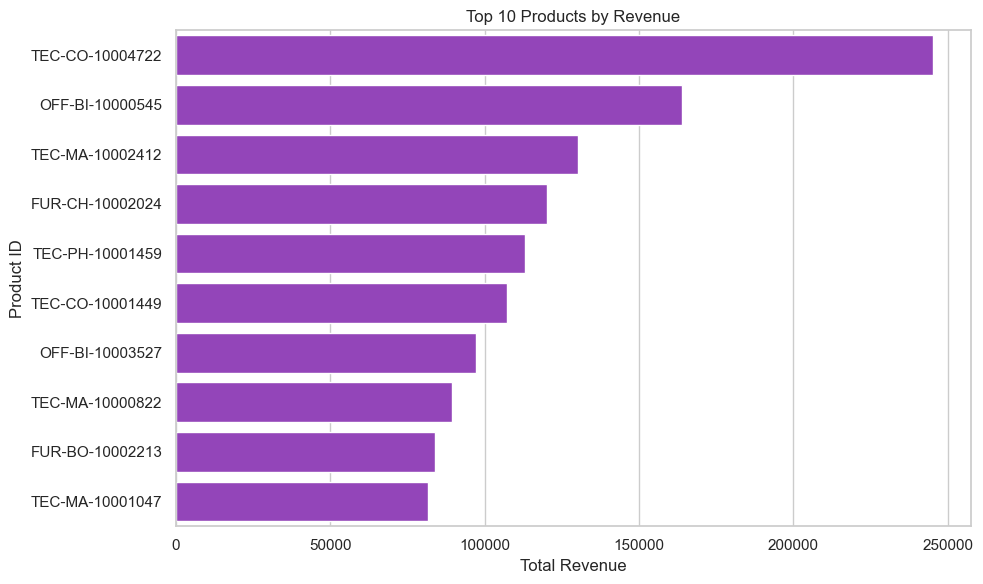

In [33]:
# ============================================================
# Visualizing Top Revenue Generating Products
# ============================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df7,
    x='revenue',
    y='product_id',
    color='darkorchid'
)

plt.xlabel("Total Revenue")

plt.ylabel("Product ID")

plt.title(
    "Top 10 Products by Revenue"
)

plt.tight_layout()

plt.show()

## Q8. What is the monthly revenue trend?

This analysis identifies revenue patterns and sales fluctuations across different months.

In [34]:
# ============================================================
# Q8. Monthly Revenue Trend Analysis
# ============================================================

query = """

SELECT
    DATE_FORMAT(order_date, '%%Y-%%m') AS month,
    SUM(total_revenue) AS revenue
FROM orders
GROUP BY month
ORDER BY month;

"""

df8 = pd.read_sql(
    query,
    engine
)

df8

,month,revenue
0,2022-01,437431.3
1,2022-02,444011.1
2,2022-03,394105.2
3,2022-04,476400.9
4,2022-05,413625.5
5,2022-06,465300.3
6,2022-07,375278.4
7,2022-08,534562.4
8,2022-09,433887.0
9,2022-10,601707.8


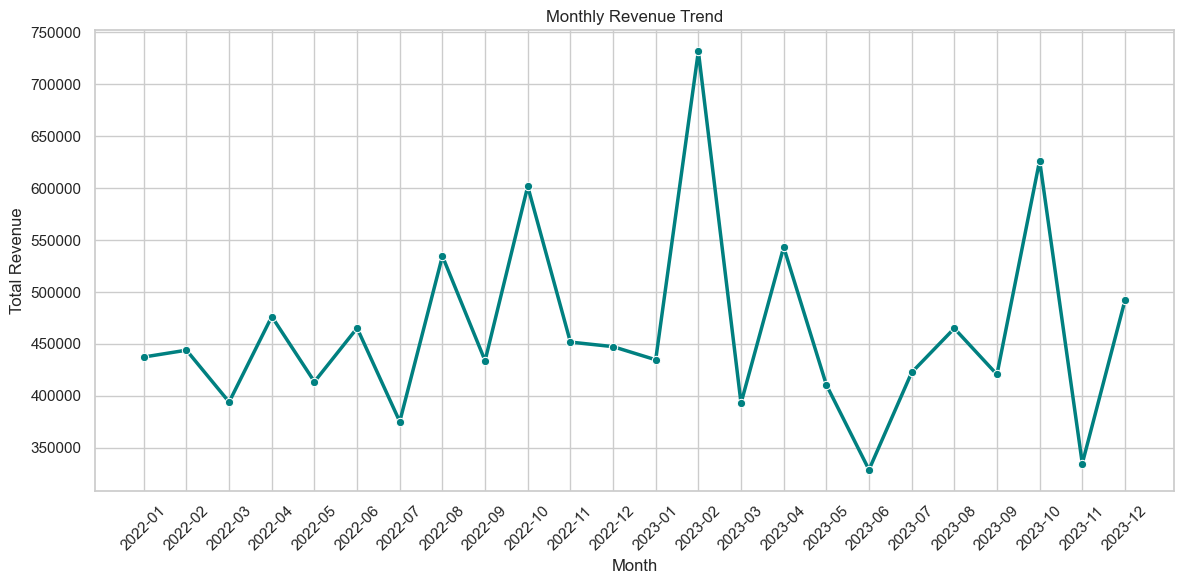

In [35]:
# ============================================================
# Visualizing Monthly Revenue Trend
# ============================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df8,
    x='month',
    y='revenue',
    color='teal',
    marker='o',
    linewidth=2.5
)

plt.xlabel("Month")

plt.ylabel("Total Revenue")

plt.title(
    "Monthly Revenue Trend"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY OF SQL ANALYSIS
# ============================================================

## Conclusion

The SQL analysis provides a clear business view of the retail dataset and highlights the main drivers of performance across revenue, profit, geography, pricing, and time.

### What the analysis shows

- **Overall performance:** The business generated strong total revenue, total profit, and order volume, showing that the dataset represents an active and sizable retail operation.
- **Category performance:** The **Technology** category contributed the highest revenue, making it the most important category from a sales perspective.
- **Profitability:** Within sub-categories, **Chairs** and **Phones** delivered the highest profit, showing that the most profitable items are not always the same as the highest-revenue items.
- **Geographic performance:** **California** was the top revenue-generating state, while **New York City** and **Los Angeles** were among the most profitable cities, indicating strong demand in major markets.
- **Discount impact:** Discounts helped increase revenue, but they reduced average profit, which means discounting should be used carefully and strategically.
- **Product performance:** A few products contributed a large share of the total revenue, showing that product mix has a strong impact on business results.
- **Monthly trend:** Revenue changed across months, with visible seasonal peaks, suggesting that demand is not constant throughout the year.

### Business takeaways

- Focus more on **high-revenue categories** like Technology.
- Protect and promote **high-profit sub-categories** such as Chairs and Phones.
- Prioritize strong markets like **California, New York City, and Los Angeles**.
- Use discounts selectively to avoid hurting margins.
- Plan inventory, promotions, and staffing around **seasonal demand patterns**.

### Final remark

Overall, the SQL analysis shows that business performance is shaped by a combination of product category, location, pricing strategy, and seasonality. These insights create a strong foundation for the machine learning profitability prediction section that follows.

# ============================================================
# MACHINE LEARNING BASED PROFITABILITY PREDICTION
# ============================================================

## Objective
The objective of this section is to build machine learning models capable of predicting whether a retail order will be profitable or loss-making based on operational and transactional features.

The predictive analysis workflow includes:
- Creating a classification target variable
- Preparing a machine learning dataset
- Performing preprocessing and feature encoding
- Training classification models
- Evaluating model performance
- Identifying important predictive features
- Saving trained models using Pickle

In [36]:
# ============================================================
# Creating Machine Learning DataFrame
# ============================================================

# Creating dedicated dataframe for Machine Learning

ml_df = df.copy()

# Creating target variable
# 1 -> Profitable Order
# 0 -> Loss-Making Order

ml_df['is_profitable'] = (
    ml_df['profit'] > 0
).astype(int)

# Dropping leakage, unnecessary,
# and high-cardinality columns

ml_df.drop(columns=[
    'profit',
    'sales_price',
    'discount',
    'total_revenue',
    'order_id',
    'order_date',
    'cost_price',
    'list_price',
    'city',
    'postal_code',
    'product_id'
], inplace=True)

# Displaying dataframe

ml_df.head()

,ship_mode,segment,state,region,category,sub_category,quantity,discount_percent,year,month,is_profitable
0,Second Class,Consumer,Kentucky,South,Furniture,Bookcases,2,2,2023,3,1
1,Second Class,Consumer,Kentucky,South,Furniture,Chairs,3,3,2023,8,1
2,Second Class,Corporate,California,West,Office Supplies,Labels,2,5,2023,1,0
3,Standard Class,Consumer,Florida,South,Furniture,Tables,5,2,2022,6,1
4,Standard Class,Consumer,Florida,South,Office Supplies,Storage,2,5,2022,7,0


## Feature Selection

The following features were retained for modeling:
- Ship Mode
- Segment
- State
- Region
- Category
- Sub Category
- Quantity
- Discount Percent
- Year
- Month

Columns causing target leakage and high-cardinality issues were removed to improve model generalization.

In [37]:
# ============================================================
# Defining Features and Target Variable
# ============================================================

X = ml_df.drop('is_profitable', axis=1)

y = ml_df['is_profitable']

print("Feature Shape :", X.shape)

print("Target Shape  :", y.shape)

Feature Shape : (9994, 10)
Target Shape  : (9994,)


In [38]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)

print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (7995, 10)
Testing Data Shape  : (1999, 10)


In [39]:
# ============================================================
# Identifying Numerical and Categorical Columns
# ============================================================

cat_cols = X_train.select_dtypes(
    include='object'
).columns

num_cols = X_train.select_dtypes(
    exclude='object'
).columns

print("Categorical Columns:\n")

print(cat_cols)

print("\nNumerical Columns:\n")

print(num_cols)

Categorical Columns:

Index(['ship_mode', 'segment', 'state', 'region', 'category', 'sub_category'], dtype='object')

Numerical Columns:

Index(['quantity', 'discount_percent', 'year', 'month'], dtype='object')


## Data Preprocessing

The preprocessing pipeline performs:
- Standard Scaling on numerical features
- One-Hot Encoding on categorical features

A ColumnTransformer is used to apply transformations efficiently within the machine learning pipeline.

In [40]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

## Model Selection

Two classification algorithms were selected:

### Logistic Regression
A linear classification algorithm commonly used for binary classification problems.

### Random Forest Classifier
An ensemble-based machine learning algorithm capable of handling non-linear relationships and complex feature interactions.

In [41]:
# ============================================================
# Logistic Regression Pipeline
# ============================================================

lr_pipeline = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [42]:
# ============================================================
# Random Forest Classifier Pipeline
# ============================================================

rf_pipeline = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])

In [43]:
# ============================================================
# Training Machine Learning Models
# ============================================================

lr_pipeline.fit(
    X_train,
    y_train
)

rf_pipeline.fit(
    X_train,
    y_train
)

print("Models trained successfully.")

Models trained successfully.


In [44]:
# ============================================================
# Generating Predictions
# ============================================================

lr_pred = lr_pipeline.predict(X_test)

rf_pred = rf_pipeline.predict(X_test)

## Model Evaluation

The following evaluation metrics are used:
- Accuracy Score
- Precision Score
- Recall Score
- F1 Score
- Classification Report
- Confusion Matrix

In [45]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(name, y_true, y_pred):

    print(f"\n{name}")

    print("-" * 50)

    print(
        "Accuracy Score : {:.2f}%".format(
            accuracy_score(
                y_true,
                y_pred
            ) * 100
        )
    )

    print(
        "Precision Score: {:.2f}%".format(
            precision_score(
                y_true,
                y_pred
            ) * 100
        )
    )

    print(
        "Recall Score   : {:.2f}%".format(
            recall_score(
                y_true,
                y_pred
            ) * 100
        )
    )

    print(
        "F1 Score       : {:.2f}%".format(
            f1_score(
                y_true,
                y_pred
            ) * 100
        )
    )

    # Classification Report

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    report_df = pd.DataFrame(
        report
    ).transpose()

    percentage_cols = [
        'precision',
        'recall',
        'f1-score'
    ]

    report_df[
        percentage_cols
    ] = (
        report_df[
            percentage_cols
        ] * 100
    ).round(2)

    print("\nClassification Report (%):\n")

    display(report_df)

    # Confusion Matrix

    print("\nConfusion Matrix:\n")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

In [46]:
# ============================================================
# Evaluating Logistic Regression
# ============================================================

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)


Logistic Regression
--------------------------------------------------
Accuracy Score : 78.09%
Precision Score: 81.21%
Recall Score   : 78.10%
F1 Score       : 79.63%

Classification Report (%):



,precision,recall,f1-score,support
0,74.60,78.07,76.30,903.00000
1,81.21,78.10,79.63,1096.00000
accuracy,78.09,78.09,78.09,0.78089
macro avg,77.91,78.09,77.96,1999.00000
weighted avg,78.23,78.09,78.12,1999.00000



Confusion Matrix:

[[705 198]
 [240 856]]


In [47]:
# ============================================================
# Evaluating Random Forest Classifier
# ============================================================

evaluate_model(
    "Random Forest Classifier",
    y_test,
    rf_pred
)


Random Forest Classifier
--------------------------------------------------
Accuracy Score : 77.29%
Precision Score: 80.51%
Recall Score   : 77.28%
F1 Score       : 78.86%

Classification Report (%):



,precision,recall,f1-score,support
0,73.71,77.30,75.46,903.000000
1,80.51,77.28,78.86,1096.000000
accuracy,77.29,77.29,77.29,0.772886
macro avg,77.11,77.29,77.16,1999.000000
weighted avg,77.44,77.29,77.33,1999.000000



Confusion Matrix:

[[698 205]
 [249 847]]


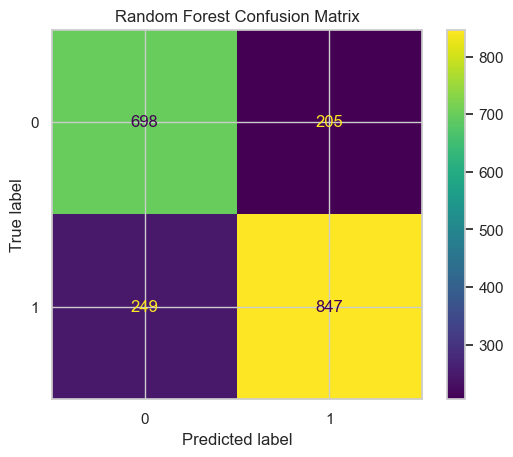

In [48]:
# ============================================================
# Confusion Matrix Visualization
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

## Feature Importance Analysis

Feature importance analysis helps identify the most influential variables contributing to profitability prediction.

In [49]:
# ============================================================
# Feature Importance Extraction
# ============================================================

ohe_columns = rf_pipeline.named_steps[
    'preprocessor'
].transformers_[1][1].get_feature_names_out(
    cat_cols
)

all_features = (
    list(num_cols)
    + list(ohe_columns)
)

importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='importance',
        ascending=False
    )
)

feature_importance_df.head(10)

,feature,importance
0,quantity,0.131604
3,month,0.128774
1,discount_percent,0.074470
65,category_Office Supplies,0.057420
2,year,0.035244
81,sub_category_Storage,0.031776
66,category_Technology,0.027683
76,sub_category_Furnishings,0.022375
7,ship_mode_Standard Class,0.022332
9,segment_Consumer,0.021866


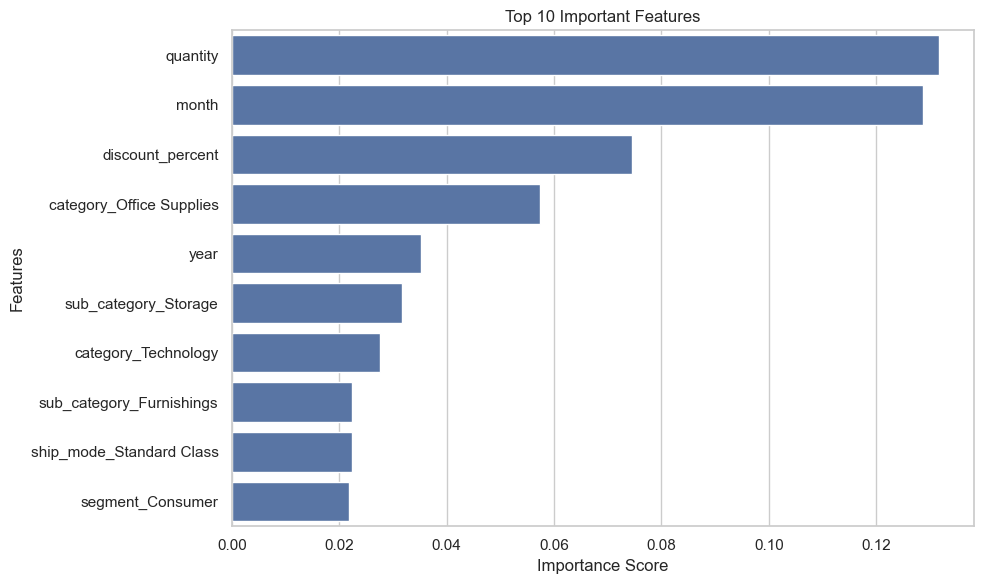

In [50]:
# ============================================================
# Top 10 Important Features Visualization
# ============================================================

top_features = (
    feature_importance_df
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.tight_layout()

plt.show()

## Model Serialization

The trained machine learning pipelines were serialized using Pickle for future reuse and deployment.

In [51]:
# ============================================================
# Saving Models using Pickle
# ============================================================

with open(
    'logistic_regression_model.pkl',
    'wb'
) as file:

    pickle.dump(
        lr_pipeline,
        file
    )

with open(
    'random_forest_classifier.pkl',
    'wb'
) as file:

    pickle.dump(
        rf_pipeline,
        file
    )

print("Models saved successfully.")

Models saved successfully.


# ============================================================
# FINAL SUMMARY OF MACHINE LEARNING ANALYSIS
# ============================================================

## Conclusion

The machine learning section focused on predicting whether a retail order would be profitable or loss-making using classification algorithms.

A separate machine learning dataframe was created from the cleaned dataset, and leakage-prone and high-cardinality columns were removed to keep the modeling task realistic and reliable.

### Workflow Followed

The machine learning workflow included:
- creating the target variable `is_profitable`
- preparing a separate dataframe for modeling
- splitting the data into training and testing sets
- preprocessing numerical and categorical features
- scaling numerical features using `StandardScaler`
- encoding categorical features using `OneHotEncoder`
- training classification models using pipelines
- evaluating model performance
- analyzing feature importance
- saving the trained pipelines using Pickle

### Models Used

Two classification models were trained:
- Logistic Regression
- Random Forest Classifier

Both models were built using Scikit-learn pipelines so that preprocessing and model training remained fully connected and reproducible.

### Model Performance

The models achieved around:
- 78% Accuracy
- 80% Precision
- 78% Recall
- 79% F1 Score

Logistic Regression performed slightly better than Random Forest on the test set, so it can be considered the better final model for this project.

### Key Observations

- The cleaned feature set was sufficient to predict profitability with reasonable accuracy.
- Category, quantity, discount percentage, region, segment, and month were useful signals for prediction.
- Removing pricing-based leakage columns made the problem more realistic and improved the quality of the analysis.

### Business Value

This model can help businesses identify potentially unprofitable orders, understand which features influence profitability, and support more informed pricing and discount decisions.

### Final Remark

The machine learning section successfully converted the retail dataset into a practical profitability classification problem using data preprocessing, pipeline-based modeling, evaluation, and model saving.

# ============================================================
# FINAL PROJECT CONCLUSION
# ============================================================

## Overall Conclusion

This project presented an end-to-end retail sales analysis workflow that combined data cleaning, feature engineering, SQL-based exploratory analysis, and machine learning.

The project showed how raw retail order data can be transformed into useful business insights and predictive models through a structured analytics pipeline.

### What the Project Achieved

- Cleaned and prepared the dataset for analysis
- Engineered useful business features such as discount, sales price, total revenue, and profit
- Created a separate SQL dataset for business intelligence queries
- Performed category, geographic, discount, product, and trend analysis using SQL
- Built a separate machine learning dataset for profitability prediction
- Trained and evaluated classification models
- Saved the final model pipelines for future use

### Main Takeaways

- Technology was the strongest revenue category
- Chairs and Phones were among the most profitable sub-categories
- California, New York City, and Los Angeles were strong business regions
- Discounts improved revenue but reduced profitability
- Logistic Regression provided the best final classification performance

### Final Insight

Overall, the project demonstrates how retail data can be used not only to understand past performance but also to support future decision-making. The SQL analysis explains what happened, while the machine learning section shows how similar outcomes can be predicted in advance.

This completes the retail sales analysis and profitability prediction project.